In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
h = 0.1
N = int(1/h) - 1
n_total = N * N

# Inicjalizacja macierzy A wypełnionej zerami
A = np.zeros((n_total, n_total))

for i in range(n_total):

    A[i, i] = -4.0

    # Sąsiad z lewej (dodajemy pod warunkiem, że punkt nie leży na lewej krawędzi)
    if i % N != 0:
        A[i, i - 1] = 1.0

    # Sąsiad z prawej (dodajemy pod warunkiem, że punkt nie leży na prawej krawędzi)
    if (i + 1) % N != 0:
        A[i, i + 1] = 1.0

    # Sąsiad "z góry" (przesunięcie o całą szerokość siatki N w tył)
    if i >= N:
        A[i, i - N] = 1.0

    # Sąsiad "z dołu" (przesunięcie o całą szerokość siatki N w przód)
    if i < n_total - N:
        A[i, i + N] = 1.0

print(A)

[[-4.  1.  0. ...  0.  0.  0.]
 [ 1. -4.  1. ...  0.  0.  0.]
 [ 0.  1. -4. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ... -4.  1.  0.]
 [ 0.  0.  0. ...  1. -4.  1.]
 [ 0.  0.  0. ...  0.  1. -4.]]


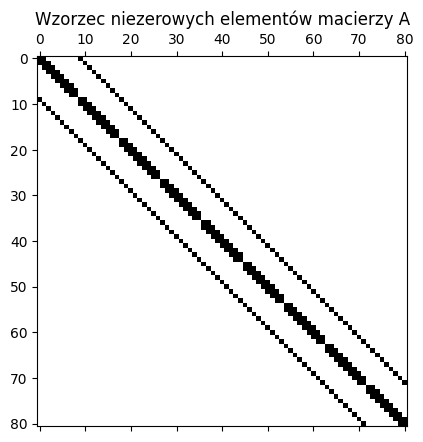

In [6]:
plt.spy(A)
plt.title("Wzorzec niezerowych elementów macierzy A")
plt.show()

In [14]:
b = np.zeros(n_total)

# Dwie pętle: po wierszach (oś Y) i kolumnach (oś X) siatki wewnętrznej
for row in range(N):
    for col in range(N):
        # 1. Obliczenie fizycznych współrzędnych x i y w dziedzinie [0,1]
        x_val = (col + 1) * h
        y_val = (row + 1) * h

        # 2. Przeliczenie indeksów z siatki 2D na pojedynczy indeks 1D
        k = row * N + col

        # 3. Wartość funkcji f(x, y) pomnożona przez h^2
        f_val = -8 * np.pi**2 * np.sin(2 * np.pi * x_val) * np.cos(2 * np.pi * y_val)
        b[k] = (h**2) * f_val

        # 4. Nałożenie warunków brzegowych

        # Jeśli punkt dotyka dolnego brzegu (y = 0)
        if row == 0:
            b[k] -= np.sin(2 * np.pi * x_val)

        # Jeśli punkt dotyka górnego brzegu (y = 1)
        if row == N - 1:
            b[k] -= np.sin(2 * np.pi * x_val)

In [15]:
D = np.diag(np.diag(A)) # Macierz z samą przekątną
R = A - D               # Macierz A bez przekątnej
D_inv = np.linalg.inv(D) # Odwrócenie D

# Zgadujemy początkowe rozwiązanie
u_numeryczne = np.zeros(n_total)

for iteracja in range(1000):
    u_nowe = np.dot(D_inv, b - np.dot(R, u_numeryczne))
    u_numeryczne = u_nowe
print(u_numeryczne)

[0.09147248 0.18094547 0.26627478 0.34496192 0.41375486 0.46773586
 0.49794233 0.48442689 0.37384138 0.08504699 0.16720174 0.24333829
 0.3097933  0.36188178 0.39301811 0.39304322 0.34525212 0.22309894
 0.0796606  0.15578781 0.22459515 0.28175615 0.32204852 0.33890787
 0.32396639 0.26707073 0.1586876  0.07599953 0.14809501 0.21214361
 0.26352846 0.29695264 0.30635013 0.28514137 0.22733314 0.13032137
 0.0744969  0.14497467 0.20718608 0.25644613 0.28748823 0.29450436
 0.27161775 0.21420609 0.121498   0.07534707 0.14680408 0.21024494
 0.26107597 0.29403585 0.30311642 0.28183424 0.22435435 0.12832305
 0.07851629 0.15352276 0.22126099 0.27744335 0.31690728 0.33318661
 0.31808045 0.2617206  0.15505012 0.08373479 0.16460262 0.23950739
 0.30482682 0.35593901 0.38636376 0.38612726 0.33886089 0.21863821
 0.09048423 0.17898633 0.26338239 0.34120131 0.40923278 0.46262939
 0.49255677 0.47931921 0.37010524]


In [19]:
def solve_poisson(h):
    """
    Funkcja budująca układ równań dla zadanego kroku h,
    zwracająca siatkę, rozwiązanie numeryczne, dokładne oraz błąd maksymalny.
    """
    N = int(1/h) - 1
    n_total = N * N

    A = np.zeros((n_total, n_total))
    b = np.zeros(n_total)

    # 1. Budowa macierzy A i wektora b
    for row in range(N):
        for col in range(N):
            k = row * N + col
            A[k, k] = -4.0

            if col != 0: A[k, k - 1] = 1.0
            if col != N - 1: A[k, k + 1] = 1.0
            if row != 0: A[k, k - N] = 1.0
            if row != N - 1: A[k, k + N] = 1.0

            # Współrzędne fizyczne
            x_val = (col + 1) * h
            y_val = (row + 1) * h

            # Funkcja wymuszająca
            f_val = -8 * np.pi**2 * np.sin(2 * np.pi * x_val) * np.cos(2 * np.pi * y_val)
            b[k] = (h**2) * f_val

            # Warunki brzegowe g(x, 0) i g(x, 1)
            if row == 0:
                b[k] -= np.sin(2 * np.pi * x_val)
            if row == N - 1:
                b[k] -= np.sin(2 * np.pi * x_val)

    # 2. Rozwiązanie układu równań
    u_num_1d = np.linalg.solve(A, b)
    u_num = u_num_1d.reshape((N, N))

    # 3. Rozwiązanie dokładne
    x = np.linspace(h, 1-h, N)
    y = np.linspace(h, 1-h, N)
    X, Y = np.meshgrid(x, y)
    u_exact = np.sin(2 * np.pi * X) * np.cos(2 * np.pi * Y)

    # Obliczenie maksymalnego błędu
    max_error = np.max(np.abs(u_exact - u_num))

    return X, Y, u_num, u_exact, max_error

<>:20: SyntaxWarning: invalid escape sequence '\h'
<>:20: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_64705/4176260075.py:20: SyntaxWarning: invalid escape sequence '\h'
  ax2.set_title('Numeryczne $\hat{u}(x,y)$ (h=0.1)')


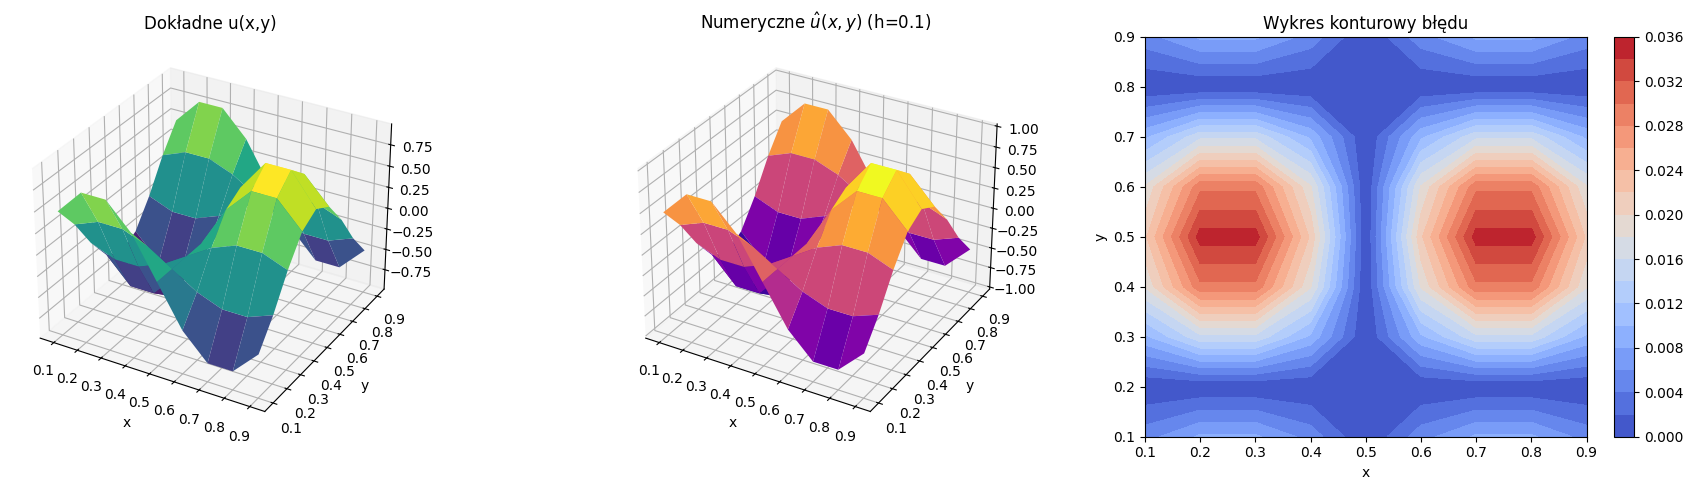

In [20]:

# WYKRESY DLA KROKU h = 0.1

h_plot = 0.1
X, Y, u_num, u_exact, _ = solve_poisson(h_plot)
error_matrix = np.abs(u_exact - u_num)

fig = plt.figure(figsize=(18, 5))

# Wykres 1: Rozwiązanie dokładne
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(X, Y, u_exact, cmap='viridis')
ax1.set_title('Dokładne u(x,y)')
ax1.set_xlabel('x')
ax1.set_ylabel('y')

# Wykres 2: Rozwiązanie numeryczne
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(X, Y, u_num, cmap='plasma')
ax2.set_title('Numeryczne $\hat{u}(x,y)$ (h=0.1)')
ax2.set_xlabel('x')
ax2.set_ylabel('y')

# Wykres 3: Błąd - wykres konturowy
ax3 = fig.add_subplot(133)
contour = ax3.contourf(X, Y, error_matrix, levels=20, cmap='coolwarm')
plt.colorbar(contour, ax=ax3)
ax3.set_title('Wykres konturowy błędu')
ax3.set_xlabel('x')
ax3.set_ylabel('y')

plt.tight_layout()
plt.show()

In [21]:
print("--- Badanie rzędu zbieżności ---")
h_values = [1/4, 1/8, 1/16, 1/32, 1/64]
errors = []

for h in h_values:
    _, _, _, _, err = solve_poisson(h)
    errors.append(err)
    print(f"Błąd dla h = 1/{int(1/h)}: {err:.6e}")

print("\n--- Rzędy zbieżności ---")
# Obliczanie empirycznego rzędu zbieżności
for i in range(len(errors) - 1):
    e1 = errors[i]
    e2 = errors[i+1]

    # Wzór na rząd zbieżności p = log2(E_h / E_{h/2})
    p = np.log2(e1 / e2)
    print(f"Krok z 1/{int(1/h_values[i])} na 1/{int(1/h_values[i+1])} -> Rząd p = {p:.4f}")

--- Badanie rzędu zbieżności ---
Błąd dla h = 1/4: 2.670863e-01
Błąd dla h = 1/8: 5.834249e-02
Błąd dla h = 1/16: 1.411294e-02
Błąd dla h = 1/32: 3.499447e-03
Błąd dla h = 1/64: 8.730740e-04

--- Rzędy zbieżności ---
Krok z 1/4 na 1/8 -> Rząd p = 2.1947
Krok z 1/8 na 1/16 -> Rząd p = 2.0475
Krok z 1/16 na 1/32 -> Rząd p = 2.0118
Krok z 1/32 na 1/64 -> Rząd p = 2.0030
